# Decision Tree Model Implementation

In this notebook, we build a **Decision Tree classifier from scratch** using only NumPy and Pandas. We apply it to the Bank Marketing dataset to predict whether a customer will subscribe to a term deposit.

## Problem Formulation

This is a **binary classification** problem. Given customer attributes $\mathbf{x} \in \mathbb{R}^d$, we want to predict whether the customer will subscribe to a term deposit:

$$y \in \{0, 1\}$$

where $y = 1$ means "yes" (subscribed) and $y = 0$ means "no".

The Decision Tree learns a set of decision rules from the training data to approximate:

$$P(y \mid \mathbf{x})$$

At each internal node, the algorithm picks a feature $x_j$ and a threshold $\tau$ to split the data into two groups. This repeats recursively until a stopping condition is hit, at which point the leaf node is assigned the majority class of its samples.

## Gini Impurity

The **Gini impurity** measures the degree of disorder (or "impurity") in a set of class labels. A node is considered *pure* if all samples belong to the same class (Gini = 0), and maximally impure when classes are equally distributed.

For a node containing $K$ classes, the Gini impurity is defined as:

$$\text{Gini} = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of samples belonging to class $k$ in the node.

For our **binary classification** problem ($K = 2$, classes 0 and 1), this simplifies to:

$$\text{Gini} = 1 - (p_0^2 + p_1^2)$$

**Interpretation:**
- $\text{Gini} = 0$: the node is perfectly pure — all samples belong to one class.
- $\text{Gini} = 0.5$: maximum impurity — classes are equally split (50/50).

The Decision Tree algorithm seeks splits that reduce Gini impurity as much as possible, thereby creating child nodes that are more homogeneous than the parent.

## Split Criteria: Weighted Gini Impurity

When evaluating a candidate split at a node, we compute the **weighted Gini impurity** of the resulting child nodes. The split divides $n$ samples into a left child of size $n_{\text{left}}$ and a right child of size $n_{\text{right}}$:

$$\text{Gini}_{\text{split}} = \frac{n_{\text{left}}}{n} \cdot \text{Gini}_{\text{left}} + \frac{n_{\text{right}}}{n} \cdot \text{Gini}_{\text{right}}$$

The weights $\frac{n_{\text{left}}}{n}$ and $\frac{n_{\text{right}}}{n}$ ensure that larger child nodes have a proportionally greater influence on the overall impurity score.

**Why minimize this?** A lower $\text{Gini}_{\text{split}}$ means the split produces child nodes that are more homogeneous in class composition. By greedily selecting the feature and threshold that minimize this quantity at each node, the tree progressively separates the classes, improving classification accuracy.

## Algorithm Description

The Decision Tree is built using a **recursive binary splitting** strategy. Starting from the root node (which contains all training samples), the algorithm proceeds as follows:

### 1. Feature Selection and Threshold Search
At each node, the algorithm iterates over **every feature** and evaluates **every unique value** of that feature as a candidate split threshold. For each candidate $(j, \tau)$, it computes the weighted Gini impurity of the resulting partition:
- **Left child:** samples where $x_j \leq \tau$
- **Right child:** samples where $x_j > \tau$

The split $(j^*, \tau^*)$ that yields the **lowest weighted Gini impurity** is selected.

### 2. Recursive Tree Growth
Once the best split is found, the dataset is partitioned into two subsets. The algorithm is then called **recursively** on each subset to build the left and right subtrees. This continues until a stopping condition is triggered.

### 3. Tree Structure
Each internal node stores:
- The splitting feature index
- The splitting threshold
- References to the left and right child subtrees

Each leaf node stores the **majority class label** of the samples that reached it.

## Stopping Conditions

Unconstrained recursive splitting would grow the tree until every leaf contains a single sample, leading to severe **overfitting**. To control tree complexity and improve generalization, we enforce the following stopping conditions:

### 1. `max_depth`
The maximum number of levels the tree is allowed to grow. When the current recursion depth reaches `max_depth`, the node is declared a leaf regardless of its impurity. This is the primary mechanism for controlling model complexity.

### 2. `min_samples_split`
The minimum number of samples required at a node to attempt a split. If a node contains fewer than `min_samples_split` samples, it is declared a leaf. This prevents the tree from making splits based on very small, potentially noisy subsets of data.

### 3. Pure Node Condition
If all samples at a node belong to the **same class** (i.e., Gini impurity = 0), there is no benefit in splitting further. The node is immediately declared a leaf with that class as its label.

Together, these conditions balance the bias-variance tradeoff: a deeper tree with fewer constraints has lower bias but higher variance, while a shallower tree generalizes better at the cost of some training accuracy.

## Leaf Node Prediction Rule

When a sample reaches a **leaf node** during tree traversal, the tree assigns it the class label and probability derived from the training samples at that leaf using **weighted majority voting**.

### Label
$$\hat{y} = \underset{k}{\operatorname{argmax}}\; w_k \cdot n_k$$

where $w_k$ is the class weight and $n_k$ is the raw sample count for class $k$. With `class_weight='balanced'`, this gives the minority class ~7.5× more influence, so a leaf predicts positive even when fewer raw samples are positive, as long as their weighted count wins.

### Probability
$$\hat{p} = \frac{w_1 \cdot n_1}{w_0 \cdot n_0 + w_1 \cdot n_1}$$

This weighted probability is consistent with the Gini criterion used during splitting, and ensures `predict()` and `predict_with_threshold(0.5)` are identical — both reduce to $w_1 n_1 > w_0 n_0$.

## Step 1: Decision Tree Implementation

We implement the `DecisionTree` class from scratch. The tree is represented as a nested dictionary structure:

- **Internal node:** `{"feature": j, "threshold": τ, "left": subtree, "right": subtree}`
- **Leaf node:** `{"label": class_value}`

All splitting logic, impurity calculations, and prediction traversal are implemented manually using NumPy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


class DecisionTree:

    def __init__(self, max_depth=5, min_samples_split=10, class_weight=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.class_weight = class_weight   # None | 'balanced' | {0: w0, 1: w1}
        self.tree = None
        self.class_weight_ = {}            # populated in fit()

    # Gini Impurity (supports sample weights) 
    def gini(self, y, w=None):
        if len(y) == 0:
            return 0.0
        if w is None:
            w = np.ones(len(y))
        total_w = w.sum()
        if total_w == 0:
            return 0.0
        p1 = w[y == 1].sum() / total_w
        p0 = 1.0 - p1
        return 1.0 - (p0 ** 2 + p1 ** 2)

    # Dataset Splitting (also splits sample weights)
    def split_dataset(self, X, y, feature, threshold, w=None):
        mask_left  = X[:, feature] <= threshold
        mask_right = ~mask_left
        if w is not None:
            return (X[mask_left],  y[mask_left],  w[mask_left],
                    X[mask_right], y[mask_right], w[mask_right])
        return (X[mask_left],  y[mask_left],  None,
                X[mask_right], y[mask_right], None)

    # Best Split Search (weighted Gini) 
    def best_split(self, X, y, w):
        n, d = X.shape
        w_total   = w.sum()
        best_gini = float('inf')
        best_info = None

        for feature in range(d):
            unique_vals = np.unique(X[:, feature])
            if len(unique_vals) < 2:
                continue

            thresholds = (unique_vals[:-1] + unique_vals[1:]) / 2.0

            for threshold in thresholds:
                X_left, y_left, w_left, X_right, y_right, w_right = \
                    self.split_dataset(X, y, feature, threshold, w)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                gini_split = (
                    (w_left.sum()  / w_total) * self.gini(y_left,  w_left) +
                    (w_right.sum() / w_total) * self.gini(y_right, w_right)
                )

                if gini_split < best_gini:
                    best_gini = gini_split
                    best_info = {
                        "feature"   : feature,
                        "threshold" : threshold,
                        "gini_split": gini_split,
                        "X_left"    : X_left,  "y_left"  : y_left,  "w_left"  : w_left,
                        "X_right"   : X_right, "y_right" : y_right, "w_right" : w_right,
                    }

        return best_info

    # Recursive Tree Builder 
    def build_tree(self, X, y, depth=0, sample_weights=None):
        n = len(y)
        w = sample_weights if sample_weights is not None else np.ones(n)

        majority_label = int(np.bincount(y.astype(int), weights=w).argmax())

        # Weighted leaf probability: consistent with the class-weighted Gini criterion.
        #
        # With 'balanced' weights (~7.5×), the tree aggressively splits minority
        # samples into smaller, purer leaves. Raw-count prob_pos = n1/n would see
        # fewer positives per leaf and return lower scores, forcing an artificially
        # low decision threshold (~0.17). Using the same class weights for scoring
        # keeps splitting and prediction on the same scale.
        #
        # Bonus: predict() and predict_with_threshold(0.5) become identical —
        # both reduce to the condition w1*n1 > w0*n0.
        w0 = self.class_weight_.get(0, 1.0)
        w1 = self.class_weight_.get(1, 1.0)
        w_pos = w1 * float((y == 1).sum())
        w_neg = w0 * float((y == 0).sum())
        prob_pos = w_pos / (w_pos + w_neg) if (w_pos + w_neg) > 0 else 0.0

        def make_leaf():
            return {"label": majority_label, "prob": prob_pos}

        if depth >= self.max_depth:         return make_leaf()
        if n     <  self.min_samples_split: return make_leaf()

        current_gini = self.gini(y, w)
        if current_gini == 0.0:             return make_leaf()

        split = self.best_split(X, y, w)
        if split is None:                   return make_leaf()

        left_subtree  = self.build_tree(
            split["X_left"],  split["y_left"],  depth + 1, split["w_left"])
        right_subtree = self.build_tree(
            split["X_right"], split["y_right"], depth + 1, split["w_right"])

        return {
            "feature"  : split["feature"],
            "threshold": split["threshold"],
            # Store n_samples and gini_gain for weighted feature importance
            "n_samples": n,
            "gini_gain": current_gini - split["gini_split"],
            "left"     : left_subtree,
            "right"    : right_subtree,
        }
    
    def fit(self, X, y):
        n       = len(y)
        classes = np.unique(y)

        if self.class_weight == 'balanced':
            self.class_weight_ = {
                c: n / (len(classes) * np.sum(y == c)) for c in classes
            }
        elif isinstance(self.class_weight, dict):
            self.class_weight_ = self.class_weight
        else:
            self.class_weight_ = {c: 1.0 for c in classes}

        sample_weights = np.array([self.class_weight_[yi] for yi in y])
        self.tree = self.build_tree(X, y, depth=0, sample_weights=sample_weights)

    def predict_one(self, sample):
        node = self.tree
        while "label" not in node:
            if sample[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["label"]

    def predict(self, X):
        return np.array([self.predict_one(sample) for sample in X])

    def predict_proba_one(self, sample):
        node = self.tree
        while "label" not in node:
            if sample[node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        return node["prob"]

    def predict_proba(self, X):
        return np.array([self.predict_proba_one(sample) for sample in X])

    def predict_with_threshold(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


print("DecisionTree class defined successfully (supports balanced / custom dict class_weight).")

DecisionTree class defined successfully (supports balanced / custom dict class_weight).


## Step 2: Load Dataset and Prepare Features

We load `cleaned_data.csv`, which was produced by `Bank_Marketing_Preprocessing.ipynb`. That notebook:
- Applied one-hot encoding to categorical variables
- Normalized numerical features
- Removed the `duration` column to prevent data leakage

Here we extract the feature matrix $X$ and the binary target $y$, and convert any boolean columns to 0/1 floats.

In [94]:
# Load the preprocessed dataset
df = pd.read_csv('cleaned_data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns[:10])} ... ({df.shape[1]} total)")
print(f"\nClass distribution:")
print(df['y_binary'].value_counts())
print(f"\nPositive rate: {df['y_binary'].mean():.3f}")

Dataset shape: (45211, 50)
Columns: ['age', 'default', 'housing', 'loan', 'day_of_week', 'campaign', 'previous', 'y', 'y_binary', 'previous_contact'] ... (50 total)

Class distribution:
y_binary
0    39922
1     5289
Name: count, dtype: int64

Positive rate: 0.117


In [95]:
# Extract features (X) and target (y)
# Drop the original string label 'y' and the binary target 'y_binary' from features
X_raw = df.drop(columns=['y', 'y_binary']).copy()
y_all = df['y_binary'].values

# Convert boolean columns to float (0.0 / 1.0)
for col in X_raw.columns:
    if X_raw[col].dtype == 'bool':
        X_raw[col] = X_raw[col].astype(float)

X_all = X_raw.values.astype(float)

print(f"Feature matrix shape : {X_all.shape}")
print(f"Target vector shape  : {y_all.shape}")
print(f"Feature names (first 8): {list(X_raw.columns[:8])}")

Feature matrix shape : (45211, 48)
Target vector shape  : (45211,)
Feature names (first 8): ['age', 'default', 'housing', 'loan', 'day_of_week', 'campaign', 'previous', 'previous_contact']


## Step 3: Train / Validation / Test Split (64 % / 16 % / 20 %)

To evaluate generalization and select hyperparameters without contaminating the final evaluation, we use a **three-way stratified split**:

| Set | Size | Purpose |
|-----|------|---------|
| **Train** | ~64 % | Grow the decision tree |
| **Validation** | ~16 % | Tune the decision threshold (Step 10) |
| **Test** | 20 % | Final, one-time performance report |

**Construction:** We first split out a 20 % test set, then split the remaining 80 % into 80/20 train/val. All splits are **stratified**: because the dataset is heavily imbalanced (~88 % negative, ~12 % positive), each subset preserves the original class ratio.

**Why a separate validation set?** Selecting the decision threshold on the same set used for final evaluation is a form of data leakage. It lets test-set statistics influence a modelling decision, optimistically biasing the reported F1. Tuning the threshold on the validation set and reporting once on the test set gives an honest estimate of real-world performance.

In [ ]:
# Stratified Train / Validation / Test Split  (≈64 % / 16 % / 20 % of total)
#
# Three-way split rationale:
#   Test  (20 %) : held-out entirely for final performance reporting.
#   Val   (16 %) : used only for threshold tuning in Step 10 — prevents data
#                  leakage from letting test-set performance guide the threshold.
#   Train (64 %) : used to grow the tree.

pos_idx = np.where(y_all == 1)[0]
neg_idx = np.where(y_all == 0)[0]

np.random.seed(42)
np.random.shuffle(pos_idx)
np.random.shuffle(neg_idx)

# Test set: 20 % of total 
n_pos_test = int(len(pos_idx) * 0.2)
n_neg_test = int(len(neg_idx) * 0.2)
test_idx   = np.concatenate([pos_idx[:n_pos_test], neg_idx[:n_neg_test]])

# Remaining 80 % → Val (20 % of remainder) + Train (80 % of remainder) 
pos_rem   = pos_idx[n_pos_test:]   # already shuffled; slice directly
neg_rem   = neg_idx[n_neg_test:]

n_pos_val = int(len(pos_rem) * 0.2)
n_neg_val = int(len(neg_rem) * 0.2)
val_idx   = np.concatenate([pos_rem[:n_pos_val], neg_rem[:n_neg_val]])
train_idx = np.concatenate([pos_rem[n_pos_val:], neg_rem[n_neg_val:]])

X_train = X_all[train_idx]; y_train = y_all[train_idx]
X_val   = X_all[val_idx];   y_val   = y_all[val_idx]
X_test  = X_all[test_idx];  y_test  = y_all[test_idx]

print(f"Training set size   : {X_train.shape[0]:>6}  (positive rate: {y_train.mean():.3f})")
print(f"Validation set size : {X_val.shape[0]:>6}  (positive rate: {y_val.mean():.3f})")
print(f"Test set size       : {X_test.shape[0]:>6}  (positive rate: {y_test.mean():.3f})")

Training set size   :  28937  (positive rate: 0.117)
Validation set size :   7233  (positive rate: 0.117)
Test set size       :   9041  (positive rate: 0.117)


## Hyperparameter Configuration

Two hyperparameters control tree complexity. Both are selected **jointly** via a 2D grid search on the validation set in Step 4, not chosen manually or swept independently.

### Optimization objective: F2-score (β=2)

The grid search and threshold sweep both optimise for **F2**, which weights Recall 4× more than Precision:

$$F_2 = \frac{5 \cdot P \cdot R}{4P + R}$$

**Business rationale:** Failing to contact a genuine subscriber (FN) costs more than calling a non-subscriber (FP).

### `max_depth`
Controls the maximum number of levels the tree can grow. Search range: **[7, 9, 11]**, centered on the optimum identified in a prior 1–15 sensitivity sweep.

| `max_depth` | Effect |
|-------------|--------|
| Very small (1–3) | High bias, low variance — underfits |
| Moderate (joint-selected) | Best generalisation on val set |
| Very large / unlimited | Low bias, high variance — overfits |

### `min_samples_split`
Minimum samples required at a node before attempting a split. Search range: **[10, 20, 50, 100, 200]**, extended from the previous [10, 20, 50] because 50 was winning at every depth, indicating the true optimum was outside the original range. Larger values prevent splits on small, noisy subsets and reduce overfitting at deep levels.

### `class_weight = 'balanced'`
The dataset is ~88 % negative, ~12 % positive. `'balanced'` sets weights to $\frac{n}{2 \cdot n_k}$:

$$w_{\text{pos}} = \frac{n}{2 \cdot n_{\text{pos}}} \approx 4.3, \quad w_{\text{neg}} = \frac{n}{2 \cdot n_{\text{neg}}} \approx 0.57 \quad \Rightarrow \text{ratio} \approx 7.5\times$$

Derived directly from the class distribution.

## Step 4: Joint Hyperparameter Grid Search + Final Model Training

We perform a **2D grid search** over `max_depth` and `min_samples_split` jointly on the **validation set**, selecting the combination that maximises the **F2-score (β=2)**.

### Why F2 instead of F1?

The F-beta score generalises F1 by controlling the relative importance of Recall vs. Precision:

$$F_\beta = \frac{(1+\beta^2) \cdot P \cdot R}{\beta^2 \cdot P + R}$$

With **β=2**, Recall is weighted 4× more than Precision in the harmonic mean:

$$F_2 = \frac{5 \cdot P \cdot R}{4P + R}$$

**Business rationale:** Missing a genuine subscriber (False Negative — we don't call them) costs more than a wasted call (False Positive — we call a non-subscriber). Penalising FN more aggressively aligns the model with the business cost structure.

### Why joint search instead of sweeping each parameter separately?

`max_depth` and `min_samples_split` interact, a deeper tree with larger `min_samples_split` can generalise better than either setting would suggest in isolation. Sweeping only `max_depth` leaves `min_samples_split` at an arbitrary fixed value with no empirical justification.

### Search space — 15 combinations:

| `max_depth` | `min_samples_split` |
|-------------|---------------------|
| 7, 9, 11 | 10, 20, 50, 100, 200 |

The depth range [7, 9, 11] is centred on the optimum found in a prior 1–15 sweep. `min_samples_split` is extended to [10, 20, 50, 100, 200] — the previous range [10, 20, 50] had 50 winning at every depth, indicating the optimal value lies further right.

In [97]:
# Step 4: 2D grid search over (max_depth × min_samples_split) on the validation set,
# then train the final model with the best combination.
#
# Optimization target: F2-score (β=2), which weights Recall 4× more than Precision
# in the harmonic mean: F2 = 5·P·R / (4P + R).
# Business rationale: missing a potential subscriber (FN) costs more than a wasted
# call (FP), so we penalise FN more heavily than a balanced F1 would.

def _f1_score(y_true, y_pred):
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    p = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    r = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def _fbeta_score(y_true, y_pred, beta=2):
    """F-beta: (1+β²)·P·R / (β²·P + R). β=2 → Recall counts 4× more than Precision."""
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    p  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    r  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    b2 = beta ** 2
    return (1 + b2) * p * r / (b2 * p + r) if (b2 * p + r) > 0 else 0.0

depths      = [7, 9, 11]
min_samples = [10, 20, 50, 100, 200]   # extended: previous range topped out at 50
results     = {}   # (depth, min_s) → {"train_f1": ..., "val_f1": ..., "val_f2": ...}
best_val_f2 = 0.0
best_params = None

print(f"  {'max_depth':>9}  {'min_samples':>11}  {'Train F1':>9}  {'Val F1':>8}  {'Val F2(β=2)':>11}")
print("  " + "─" * 62)

for d in depths:
    for ms in min_samples:
        dt = DecisionTree(max_depth=d, min_samples_split=ms, class_weight='balanced')
        dt.fit(X_train, y_train)
        f1_tr  = _f1_score(  y_train, dt.predict_with_threshold(X_train, 0.5))
        f1_val = _f1_score(  y_val,   dt.predict_with_threshold(X_val,   0.5))
        f2_val = _fbeta_score(y_val,  dt.predict_with_threshold(X_val,   0.5), beta=2)
        results[(d, ms)] = {"train_f1": f1_tr, "val_f1": f1_val, "val_f2": f2_val}
        marker = "  ← best" if f2_val > best_val_f2 else ""
        if f2_val > best_val_f2:
            best_val_f2 = f2_val
            best_params = (d, ms)
        print(f"  {d:>9}  {ms:>11}  {f1_tr:>9.4f}  {f1_val:>8.4f}  {f2_val:>11.4f}{marker}")

best_depth, best_min_samples = best_params
print(f"\nBest (max Val F2): max_depth={best_depth}, min_samples_split={best_min_samples}  "
      f"(val F2 = {best_val_f2:.4f})")

# Train final model with auto-selected hyperparameters
tree = DecisionTree(max_depth=best_depth, min_samples_split=best_min_samples,
                    class_weight='balanced')
tree.fit(X_train, y_train)
print(f"Class weights: { {k: round(v, 3) for k, v in tree.class_weight_.items()} }")

  max_depth  min_samples   Train F1    Val F1  Val F2(β=2)
  ──────────────────────────────────────────────────────────────
          7           10     0.4538    0.4350       0.4955  ← best
          7           20     0.4530    0.4356       0.4964  ← best
          7           50     0.4522    0.4366       0.4981  ← best
          7          100     0.4507    0.4372       0.4984  ← best
          7          200     0.4470    0.4337       0.4971
          9           10     0.4934    0.4536       0.5007  ← best
          9           20     0.4913    0.4538       0.5020  ← best
          9           50     0.4863    0.4556       0.5059  ← best
          9          100     0.4797    0.4587       0.5105  ← best
          9          200     0.4720    0.4479       0.5044
         11           10     0.5170    0.4343       0.4808
         11           20     0.5107    0.4343       0.4838
         11           50     0.5006    0.4369       0.4893
         11          100     0.4873    0.4352

## Step 5: Generate Predictions

We generate predictions using `predict_with_threshold(X, 0.5)`.

**`predict()` vs `predict_with_threshold(0.5)` — now equivalent**

With the updated weighted leaf probability, the two methods are **mathematically identical**:

- `predict()` assigns label 1 when $w_1 \cdot n_1 > w_0 \cdot n_0$ (weighted majority vote at the leaf)
- `predict_with_threshold(X, 0.5)` assigns label 1 when $\hat{p} = \dfrac{w_1 n_1}{w_0 n_0 + w_1 n_1} \geq 0.5$, i.e., $w_1 n_1 \geq w_0 n_0$

These are the same condition. The distinction existed previously because the old unweighted `prob_pos = n1/n` and the weighted `majority_label` used different decision rules — `predict()` had an implicit threshold of $\frac{1}{1+r}$ (e.g. ~0.12 with balanced weights), which was inconsistent with the 0.5 used everywhere else. Now both are derived from weighted counts and are consistent.

We continue to use `predict_with_threshold(X, 0.5)` explicitly to keep the code readable and directly comparable to Step 10's threshold sweep.

In [98]:
# predict_with_threshold(0.5) is now equivalent to predict() after the weighted
# leaf probability fix — both use the condition w1*n1 > w0*n0. We keep
# predict_with_threshold for explicitness and comparability with Step 10.
y_pred_train = tree.predict_with_threshold(X_train, 0.5)
y_pred_test  = tree.predict_with_threshold(X_test,  0.5)

print(f"Predictions generated for {len(y_pred_test)} test samples.")
print(f"Predicted class distribution (test): {dict(zip(*np.unique(y_pred_test, return_counts=True)))}")

Predictions generated for 9041 test samples.
Predicted class distribution (test): {np.int64(0): np.int64(7598), np.int64(1): np.int64(1443)}


## Step 6: Evaluation Metrics

We evaluate the model using four standard classification metrics, all computed manually from the **confusion matrix** without any library functions.

### Confusion Matrix
All metrics derive from four counts obtained by comparing predicted labels $\hat{y}$ against ground-truth labels $y$:

| | Predicted Negative | Predicted Positive |
|---|---|---|
| **Actual Negative** | TN (True Negative) | FP (False Positive) |
| **Actual Positive** | FN (False Negative) | TP (True Positive) |

### Accuracy
The fraction of all samples classified correctly:

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

> **Caution:** Under class imbalance (e.g., 88% negative), a model that always predicts "no" achieves 88% accuracy without learning anything useful. Accuracy alone is therefore a misleading metric for this dataset.

### Precision
Of all samples predicted as positive (subscribed), what fraction truly subscribed?

$$\text{Precision} = \frac{TP}{TP + FP}$$

High precision means few false alarms — the model is conservative in predicting "yes".

### Recall (Sensitivity)
Of all samples that truly subscribed, what fraction did the model correctly identify?

$$\text{Recall} = \frac{TP}{TP + FN}$$

High recall means the model catches most actual subscribers, at the cost of potentially more false positives.

### F1-Score
The **harmonic mean** of Precision and Recall, providing a single balanced metric:

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The F1-score penalises extreme imbalances between precision and recall. It is the **primary evaluation metric** for this imbalanced dataset, as it rewards models that are both precise and comprehensive in identifying subscribers.

In [99]:
def confusion_matrix_counts(y_true, y_pred):
    TP = int(((y_pred == 1) & (y_true == 1)).sum())
    FP = int(((y_pred == 1) & (y_true == 0)).sum())
    TN = int(((y_pred == 0) & (y_true == 0)).sum())
    FN = int(((y_pred == 0) & (y_true == 1)).sum())
    return TP, FP, TN, FN


def compute_metrics(y_true, y_pred, label=""):
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)

    accuracy  = (TP + TN) / (TP + FP + TN + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    f2        = (5 * precision * recall / (4 * precision + recall)
                 if (4 * precision + recall) > 0 else 0.0)

    print(f"\n{'='*45}\n  {label}\n{'='*45}")
    print(f"  Confusion Matrix:")
    print(f"              Pred no   Pred yes")
    print(f"  True no    {TN:>6}    {FP:>6}   (TN / FP)")
    print(f"  True yes   {FN:>6}    {TP:>6}   (FN / TP)")
    print(f"\n  Accuracy  : {accuracy:.4f}")
    print(f"  Precision : {precision:.4f}  — of predicted yes, how many are truly yes")
    print(f"  Recall    : {recall:.4f}  — of true yes, how many did we catch")
    print(f"  F1 Score  : {f1:.4f}  — harmonic mean of precision & recall")
    print(f"  F2 Score  : {f2:.4f}  — recall-weighted (β=2)")

    return {
        "accuracy" : accuracy,
        "precision": precision,
        "recall"   : recall,
        "f1"       : f1,
        "f2"       : f2,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
    }


train_metrics = compute_metrics(y_train, y_pred_train, "Train Set")
test_metrics  = compute_metrics(y_test,  y_pred_test,  "Test Set")


  Train Set
  Confusion Matrix:
              Pred no   Pred yes
  True no     22639      2912   (TN / FP)
  True yes     1399      1987   (FN / TP)

  Accuracy  : 0.8510
  Precision : 0.4056  — of predicted yes, how many are truly yes
  Recall    : 0.5868  — of true yes, how many did we catch
  F1 Score  : 0.4797  — harmonic mean of precision & recall
  F2 Score  : 0.5387  — recall-weighted (β=2)

  Test Set
  Confusion Matrix:
              Pred no   Pred yes
  True no      7100       884   (TN / FP)
  True yes      498       559   (FN / TP)

  Accuracy  : 0.8471
  Precision : 0.3874  — of predicted yes, how many are truly yes
  Recall    : 0.5289  — of true yes, how many did we catch
  F1 Score  : 0.4472  — harmonic mean of precision & recall
  F2 Score  : 0.4929  — recall-weighted (β=2)


## Step 7: Visualisation — Confusion Matrix

Here we plot the confusion matrix for the test set as a heatmap. This gives a quick visual summary of where the model is right and where it makes mistakes.

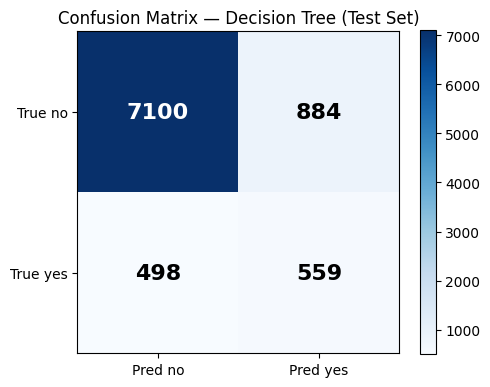

In [100]:
# Confusion Matrix Heatmap (Test Set)
cm_vals = np.array([
    [test_metrics["TN"], test_metrics["FP"]],
    [test_metrics["FN"], test_metrics["TP"]]
])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm_vals, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred no", "Pred yes"])
ax.set_yticklabels(["True no", "True yes"])
ax.set_title("Confusion Matrix — Decision Tree (Test Set)", fontsize=12)

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_vals[i, j]),
                ha="center", va="center", fontsize=16, fontweight="bold",
                color="white" if cm_vals[i, j] > cm_vals.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("dt_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Feature Importance

We measure **feature importance** by the total weighted Gini impurity reduction each feature contributes across all splits in the trained tree. Concretely, for every internal node where feature $j$ is used as the split criterion:

$$\text{importance}_j \mathrel{+}= \frac{n_\text{node}}{n_\text{train}} \times \left(\text{Gini}_\text{before} - \text{Gini}_\text{weighted split}\right)$$

where $n_\text{node}$ is the number of training samples that reach that node and $\text{Gini}_\text{before} - \text{Gini}_\text{weighted split}$ is the impurity reduction achieved by the split.

This **Mean Decrease in Impurity (MDI)** formula (identical to scikit-learn's default) correctly discounts splits deep in the tree that affect only a small fraction of samples. In contrast, counting splits equally regardless of depth would overstate the importance of features used for fine-grained splitting near the leaves.

Raw importances are normalised to sum to 1 for interpretability.

In [101]:
def compute_feature_importances(node, n_features, n_total, importances=None):
    if importances is None:
        importances = np.zeros(n_features)

    if "label" in node:
        return importances  # leaf node — no split

    # Weight each split by (fraction of training samples reaching this node)
    # multiplied by (the Gini impurity reduction it achieves).
    # This matches scikit-learn's MDI formula and correctly discounts splits
    # deep in the tree that affect only a small fraction of samples.
    importances[node["feature"]] += (node["n_samples"] / n_total) * node["gini_gain"]
    compute_feature_importances(node["left"],  n_features, n_total, importances)
    compute_feature_importances(node["right"], n_features, n_total, importances)
    return importances


feature_names = list(X_raw.columns)
n_features    = X_all.shape[1]

raw_importances = compute_feature_importances(tree.tree, n_features, len(y_train))

# Normalise to sum to 1
total = raw_importances.sum()
importances_norm = raw_importances / total if total > 0 else raw_importances

# Display top 15 features
sorted_idx = np.argsort(importances_norm)[::-1]
top_n = 15

print("Top 15 Most Important Features (Gini gain × sample fraction, normalised):")
print(f"  {'Feature':<35} {'Importance':>10}")
print("  " + "─" * 48)
for i in sorted_idx[:top_n]:
    if importances_norm[i] > 0:
        print(f"  {feature_names[i]:<35} {importances_norm[i]:>10.4f}")

Top 15 Most Important Features (Gini gain × sample fraction, normalised):
  Feature                             Importance
  ────────────────────────────────────────────────
  poutcome_success                        0.2744
  contact_unknown                         0.1786
  day_of_week                             0.0878
  housing                                 0.0674
  balance                                 0.0524
  pdays_clean                             0.0456
  month_jul                               0.0397
  month_aug                               0.0326
  age                                     0.0305
  campaign                                0.0267
  month_jun                               0.0257
  marital_married                         0.0176
  month_nov                               0.0165
  month_mar                               0.0150
  month_may                               0.0142


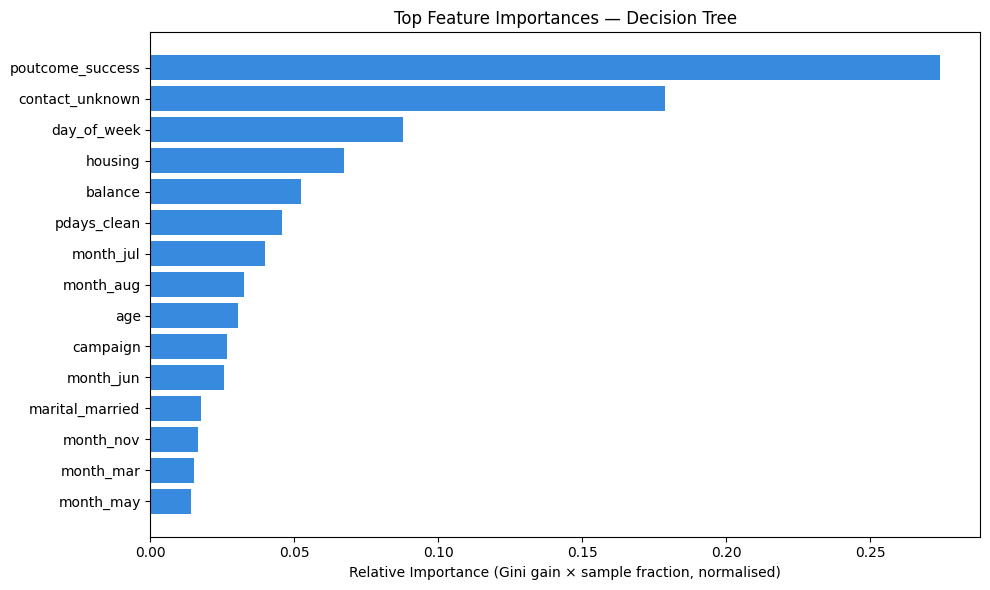

In [102]:
# Feature Importance Bar Chart
top_names  = [feature_names[i] for i in sorted_idx[:top_n] if importances_norm[i] > 0]
top_scores = [importances_norm[i] for i in sorted_idx[:top_n] if importances_norm[i] > 0]

plt.figure(figsize=(10, 6))
plt.barh(top_names[::-1], top_scores[::-1], color="#378ADD")
plt.xlabel("Relative Importance (Gini gain × sample fraction, normalised)")
plt.title("Top Feature Importances — Decision Tree")
plt.tight_layout()
plt.savefig("dt_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 9: Hyperparameter Sensitivity — Grid Search Heatmap

The 2D grid search was already computed in Step 4. Here we visualise the **Val F2 (β=2)** for all 15 (max\_depth × min\_samples\_split) combinations as a heatmap.

- **Columns** (`min_samples_split`): larger values produce coarser leaves, reducing noise sensitivity at deeper levels
- **Rows** (`max_depth`): deeper trees fit training data better but risk overfitting
- The selected combination (**★**) has the highest Val F2 in the grid

The extended range (up to `min_samples_split=200`) reveals whether the optimum has shifted right compared to the previous search that topped out at 50.

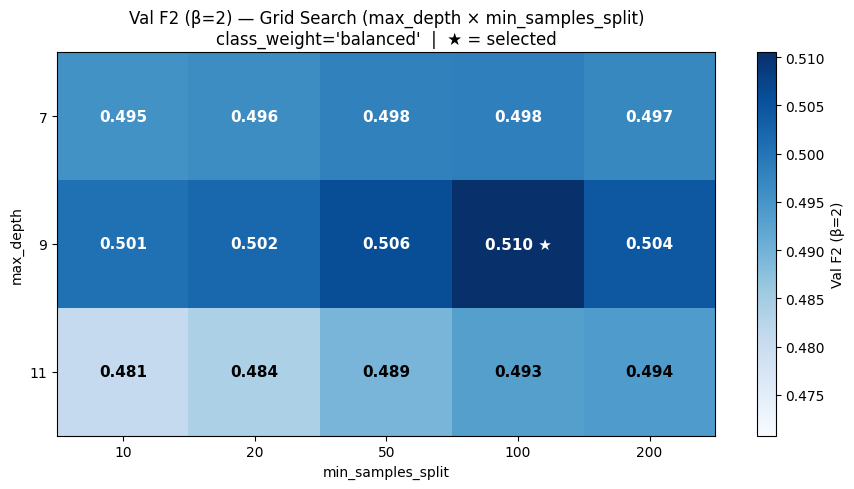


Selected: max_depth=9, min_samples_split=100
Val F2 (β=2) = 0.5105


In [103]:
# Step 9: Visualise the 2D grid search as a heatmap (computed in Step 4)
# Primary metric: Val F2 (β=2) — the Recall-driven selection criterion.
val_f2_matrix = np.array([
    [results[(d, ms)]["val_f2"] for ms in min_samples]
    for d in depths
])

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(val_f2_matrix, cmap="Blues", aspect="auto",
               vmin=val_f2_matrix.min() - 0.01)
ax.set_xticks(range(len(min_samples)))
ax.set_yticks(range(len(depths)))
ax.set_xticklabels([str(ms) for ms in min_samples])
ax.set_yticklabels([str(d)  for d  in depths])
ax.set_xlabel("min_samples_split")
ax.set_ylabel("max_depth")
ax.set_title("Val F2 (β=2) — Grid Search (max_depth × min_samples_split)\n"
             "class_weight='balanced'  |  ★ = selected")

for i, d in enumerate(depths):
    for j, ms in enumerate(min_samples):
        f2  = val_f2_matrix[i, j]
        txt = f"{f2:.3f}" + (" ★" if (d, ms) == (best_depth, best_min_samples) else "")
        col = "white" if f2 >= val_f2_matrix.max() - 0.015 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=11, color=col, fontweight="bold")

plt.colorbar(im, ax=ax, label="Val F2 (β=2)")
plt.tight_layout()
plt.savefig("dt_depth_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSelected: max_depth={best_depth}, min_samples_split={best_min_samples}")
print(f"Val F2 (β=2) = {best_val_f2:.4f}")

## Step 10: Precision-Recall Curve, Optimal Threshold & AUC

The default decision threshold is **0.5**: a sample is predicted positive if the leaf probability $\hat{p} \geq 0.5$. Because the dataset is imbalanced and we prioritise Recall, the optimal threshold typically lies **below 0.5** — accepting more false positives to catch more true positives.

### Methodology (no data leakage)

We tune the threshold on the **validation set** and report the final hard-label metrics only on the **test set**.

1. **PR curve (val set)** — sweep 200 thresholds, compute Precision and Recall at each point on the validation set and visualise the trade-off.
2. **Best threshold** — the threshold that maximises **F2** on the validation set (Recall-weighted, consistent with grid search in Step 4).
3. **AUC-PR and AUC-ROC (test set)** — threshold-independent summary statistics computed via the trapezoidal rule.
   - *AUC-PR baseline* ≈ positive rate (~0.117) for a random classifier.
   - *AUC-ROC baseline* = 0.500 for a random classifier.
4. **Final evaluation** — apply the val-set-selected threshold to the test set for the definitive precision/recall/F1/F2 report.

### F1 vs. F2 threshold plot

The right panel overlays both curves to show the trade-off: the F1-optimal threshold is higher (more conservative), while the F2-optimal threshold is lower (more aggressive toward Recall). Choosing between them is a business decision.

Best threshold (val F2)   : 0.623
  Precision (val)         : 0.4245
  Recall    (val)         : 0.5414
  F1        (val)         : 0.4758
  F2        (val)         : 0.5131


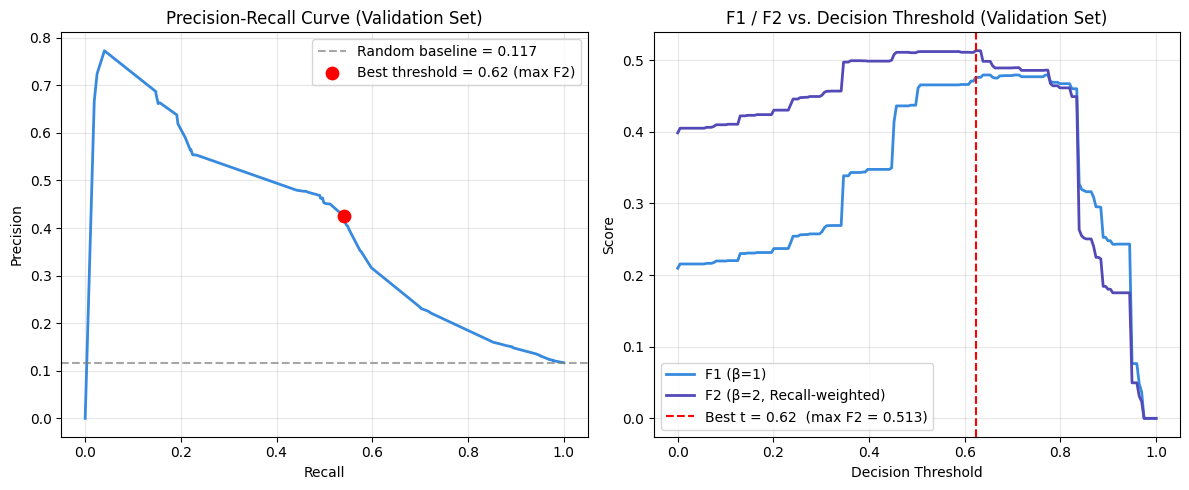


Test set AUC (threshold-independent):
  AUC-PR  : 0.4177  (random-classifier baseline ≈ 0.117)
  AUC-ROC : 0.7587  (random-classifier baseline = 0.500)

--- Final evaluation: threshold = 0.623 (tuned on val F2, applied to test) ---

  Test Set (threshold = 0.623, tuned on F2)
  Confusion Matrix:
              Pred no   Pred yes
  True no      7219       765   (TN / FP)
  True yes      518       539   (FN / TP)

  Accuracy  : 0.8581
  Precision : 0.4133  — of predicted yes, how many are truly yes
  Recall    : 0.5099  — of true yes, how many did we catch
  F1 Score  : 0.4566  — harmonic mean of precision & recall
  F2 Score  : 0.4872  — recall-weighted (β=2)


{'accuracy': 0.8580909191461121,
 'precision': 0.4133435582822086,
 'recall': 0.5099337748344371,
 'f1': 0.45658619229140196,
 'f2': 0.48716558206796823,
 'TP': 539,
 'FP': 765,
 'TN': 7219,
 'FN': 518}

In [ ]:
# Step 10: Precision-Recall Curve, Optimal Threshold & AUC Metrics
#
# Threshold selection criterion: F2-score (β=2), consistent with the Recall-driven
# grid search in Step 4. The threshold that maximises F2 on the validation set
# biases toward higher Recall at the cost of some Precision.
#
# Methodology to avoid data leakage:
#   1. Sweep thresholds on the VALIDATION set → pick the best F2 threshold.
#   2. Compute AUC-PR and AUC-ROC on the TEST set (threshold-independent).
#   3. Apply the best threshold to the TEST set for the final hard-label eval.

proba_val  = tree.predict_proba(X_val)
proba_test = tree.predict_proba(X_test)
thresholds = np.linspace(0.0, 1.0, 200)

# Threshold sweep on validation set 
val_prec, val_rec, val_f1, val_f2 = [], [], [], []
for t in thresholds:
    y_t = (proba_val >= t).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_val, y_t)
    p  = TP / (TP + FP) if (TP + FP) > 0 else 1.0
    r  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = 2 * p * r / (p + r)       if (p + r)     > 0 else 0.0
    f2 = 5 * p * r / (4 * p + r)   if (4*p + r)   > 0 else 0.0   # β=2
    val_prec.append(p); val_rec.append(r); val_f1.append(f1); val_f2.append(f2)

best_idx = int(np.argmax(val_f2))   # Recall-driven: select on F2, not F1
best_t   = thresholds[best_idx]
print(f"Best threshold (val F2)   : {best_t:.3f}")
print(f"  Precision (val)         : {val_prec[best_idx]:.4f}")
print(f"  Recall    (val)         : {val_rec[best_idx]:.4f}")
print(f"  F1        (val)         : {val_f1[best_idx]:.4f}")
print(f"  F2        (val)         : {val_f2[best_idx]:.4f}")

# Plot: PR curve and F1/F2 vs threshold (validation set) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(val_rec, val_prec, color="#378ADD", lw=2)
axes[0].axhline(y_val.mean(), color="gray", linestyle="--", alpha=0.7,
                label=f"Random baseline = {y_val.mean():.3f}")
axes[0].scatter([val_rec[best_idx]], [val_prec[best_idx]],
                color="red", zorder=5, s=80,
                label=f"Best threshold = {best_t:.2f} (max F2)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve (Validation Set)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, val_f1, color="#378ADD", lw=2, label="F1 (β=1)")
axes[1].plot(thresholds, val_f2, color="#534AB7", lw=2, label="F2 (β=2, Recall-weighted)")
axes[1].axvline(best_t, color="red", linestyle="--",
                label=f"Best t = {best_t:.2f}  (max F2 = {val_f2[best_idx]:.3f})")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("F1 / F2 vs. Decision Threshold (Validation Set)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dt_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# AUC-PR and AUC-ROC on test set (threshold-independent)
test_prec, test_rec, test_fpr_list = [], [], []
for t in thresholds:
    y_t = (proba_test >= t).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_test, y_t)
    p   = TP / (TP + FP) if (TP + FP) > 0 else 1.0
    r   = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
    test_prec.append(p); test_rec.append(r); test_fpr_list.append(fpr)

test_prec = np.array(test_prec)
test_rec  = np.array(test_rec)
test_fpr  = np.array(test_fpr_list)

# AUC-PR: integrate precision w.r.t. recall (trapezoidal rule)
sort_pr = np.argsort(test_rec)
auc_pr  = float(np.trapezoid(test_prec[sort_pr], test_rec[sort_pr]))

# AUC-ROC: integrate TPR (recall) w.r.t. FPR (trapezoidal rule)
sort_roc = np.argsort(test_fpr)
auc_roc  = float(np.trapezoid(test_rec[sort_roc], test_fpr[sort_roc]))

print(f"\nTest set AUC (threshold-independent):")
print(f"  AUC-PR  : {auc_pr:.4f}  (random-classifier baseline ≈ {y_test.mean():.3f})")
print(f"  AUC-ROC : {auc_roc:.4f}  (random-classifier baseline = 0.500)")

# Final hard-label evaluation: best threshold applied to test set 
print(f"\n--- Final evaluation: threshold = {best_t:.3f} (tuned on val F2, applied to test) ---")
y_pred_best = tree.predict_with_threshold(X_test, threshold=best_t)
compute_metrics(y_test, y_pred_best, f"Test Set (threshold = {best_t:.3f}, tuned on F2)")

## Step 11: Gain Curve, Cumulative Gains & ALIFT

### Intuition Behind Lift

Suppose the bank database has 1,000 customers, 100 of whom will actually subscribe (10% base rate).

**Without a model — random calling:**
- Call 100 people → expect ~10 subscribers
- Call 500 people → expect ~50 subscribers

**With a model — rank by predicted probability, call highest-score customers first:**
- Call 100 people → might find ~40 subscribers
- Call 500 people → might find ~79 subscribers

$$\text{Lift} = \frac{\text{Subscribers found by model}}{\text{Subscribers found by random calling}}$$

---

### How to Draw the Cumulative Gains Curve

**Step 1:** The model assigns each customer a predicted subscription probability (0 to 1).

**Step 2:** Sort customers by score from highest to lowest and split into 10 deciles:

| Rank | Customer Group | Predicted Prob | Actual Subscribers |
|------|---------------|----------------|--------------------|
| Top 10% | Most likely | 0.8 – 1.0 | ~40 people |
| 10–20% | Next likely | 0.6 – 0.8 | ~20 people |
| 20–30% | | 0.4 – 0.6 | ~10 people |
| ⋮ | ⋮ | ⋮ | ⋮ |
| Bottom 10% | Least likely | 0.0 – 0.1 | ~2 people |

**Step 3:** Plot the cumulative gains curve:
- **Y-axis:** cumulative % of all true subscribers captured
- **X-axis:** % of all customers contacted (sorted by model score)

```
100% |·················· Perfect model
     |              ·
 79% |··········★  ·      ← contact top 50% → capture 79% of subscribers
     |         /| ·
 50% |-- -- --/ |·- -- -- Random baseline (diagonal)
     |       /·  |
     |     ·/    |
   0%|····/________|_______
     0%  50%            100%   % Customers Contacted
```

The curve bowing toward the **upper-left** means subscribers are concentrated among top-ranked contacts — the model is doing useful work.

---

### ALIFT — Area Under the Cumulative Gains Curve

ALIFT condenses the entire gains curve into a **single number**:

$$\text{ALIFT} = \int_0^1 \text{Gains}(x)\, dx \quad \text{(trapezoidal rule)}$$

| Curve | Area | Meaning |
|-------|------|---------|
| Random baseline (diagonal) | **0.5000** | No better than random calling |
| Perfect model | **$\approx 1 - \text{base\_rate}/2 \approx 0.94$** | Always calls real subscribers first |
| This model | **see output below** | Higher = better targeting efficiency |

- **0.5** = as bad as random dialling
- **≈ 0.94** = theoretical maximum for this dataset (base rate ≈ 11.7%)
- Values in between reflect how effectively the model concentrates subscribers near the top of the ranked list

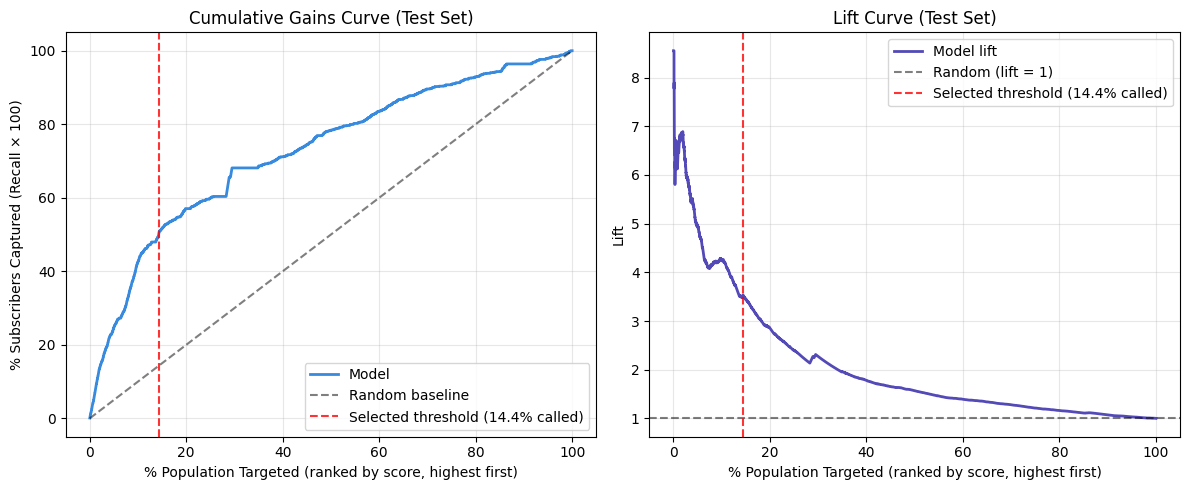

ALIFT (area under Cumulative Gains Curve):
  Random baseline (diagonal) : 0.5000
  Perfect model              : 0.9415  (= 1 - base_rate/2)
  This model                 : 0.7290
  Improvement over random    : +0.2290

Decile Analysis — ranked by predicted probability (Test Set):
    Decile   Precision    Recall    Lift         Found
  ──────────────────────────────────────────────────────────
   Top 10%      0.4989    0.4267    4.27     451 / 1057
   Top 20%      0.3335    0.5705    2.85     603 / 1057
   Top 30%      0.2655    0.6812    2.27     720 / 1057
   Top 40%      0.2080    0.7114    1.78     752 / 1057
   Top 50%      0.1832    0.7833    1.57     828 / 1057
   Top 60%      0.1628    0.8354    1.39     883 / 1057
   Top 70%      0.1497    0.8959    1.28     947 / 1057
   Top 80%      0.1358    0.9290    1.16     982 / 1057
   Top 90%      0.1252    0.9640    1.07    1019 / 1057
  Top 100%      0.1169    1.0000    1.00    1057 / 1057


In [ ]:
# Step 11: Lift Curve, Cumulative Gains & ALIFT (Test Set)

sort_idx       = np.argsort(proba_test)[::-1]   # rank by score, highest first
y_sorted       = y_test[sort_idx]
n_total        = len(y_test)
n_pos_total    = int(y_test.sum())
base_rate_test = float(y_test.mean())

pct_targeted = np.arange(1, n_total + 1) / n_total * 100
cum_pos      = np.cumsum(y_sorted)
gains        = cum_pos / n_pos_total * 100                              # % subscribers captured
lift_vals    = (cum_pos / np.arange(1, n_total + 1)) / base_rate_test  # lift at each k

# Operating point: % of population called at the selected threshold
n_at_thresh   = int((proba_test >= best_t).sum())
pct_at_thresh = n_at_thresh / n_total * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cumulative Gains
axes[0].plot(pct_targeted, gains, color="#378ADD", lw=2, label="Model")
axes[0].plot([0, 100], [0, 100], "k--", alpha=0.5, label="Random baseline")
axes[0].axvline(pct_at_thresh, color="red", linestyle="--", alpha=0.8,
                label=f"Selected threshold ({pct_at_thresh:.1f}% called)")
axes[0].set_xlabel("% Population Targeted (ranked by score, highest first)")
axes[0].set_ylabel("% Subscribers Captured (Recall × 100)")
axes[0].set_title("Cumulative Gains Curve (Test Set)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Lift Curve 
axes[1].plot(pct_targeted, lift_vals, color="#534AB7", lw=2, label="Model lift")
axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.5, label="Random (lift = 1)")
axes[1].axvline(pct_at_thresh, color="red", linestyle="--", alpha=0.8,
                label=f"Selected threshold ({pct_at_thresh:.1f}% called)")
axes[1].set_xlabel("% Population Targeted (ranked by score, highest first)")
axes[1].set_ylabel("Lift")
axes[1].set_title("Lift Curve (Test Set)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("dt_lift_curve.png", dpi=150, bbox_inches="tight")
plt.show()

# ALIFT (Area under Cumulative Gains Curve) 
alift        = float(np.trapezoid(gains / 100, pct_targeted / 100))
perfect_area = 1.0 - base_rate_test / 2   # area under perfect model gains curve

print(f"ALIFT (area under Cumulative Gains Curve):")
print(f"  Random baseline (diagonal) : 0.5000")
print(f"  Perfect model              : {perfect_area:.4f}  (= 1 - base_rate/2)")
print(f"  This model                 : {alift:.4f}")
print(f"  Improvement over random    : +{alift - 0.5:.4f}")

# Decile table 
print(f"\nDecile Analysis — ranked by predicted probability (Test Set):")
print(f"  {'Decile':>8}  {'Precision':>10}  {'Recall':>8}  {'Lift':>6}  {'Found':>12}")
print("  " + "─" * 58)
for pct in range(10, 101, 10):
    k       = int(n_total * pct / 100)
    prec_k  = float(cum_pos[k - 1]) / k
    rec_k   = float(cum_pos[k - 1]) / n_pos_total
    lift_k  = prec_k / base_rate_test
    n_found = int(cum_pos[k - 1])
    print(f"  {'Top '+str(pct)+'%':>8}  {prec_k:>10.4f}  {rec_k:>8.4f}  {lift_k:>6.2f}  {n_found:>6} / {n_pos_total}")

In [107]:
# alift is computed in Step 11 (uses proba_test rankings)
print("Summary of Results (threshold = 0.5)")
print(f"{'Metric':<12}  {'Train Set':>10}  {'Test Set':>10}")
print("  " + "─" * 36)
for key, label in [("accuracy","Accuracy"), ("precision","Precision"),
                    ("recall","Recall"), ("f1","F1-Score"), ("f2","F2-Score")]:
    print(f"  {label:<10}  {train_metrics[key]:>10.4f}  {test_metrics[key]:>10.4f}")
print(f"  {'ALIFT':<10}  {'—':>10}  {alift:>10.4f}  (random = 0.5)")

Summary of Results (threshold = 0.5)
Metric         Train Set    Test Set
  ────────────────────────────────────
  Accuracy        0.8510      0.8471
  Precision       0.4056      0.3874
  Recall          0.5868      0.5289
  F1-Score        0.4797      0.4472
  F2-Score        0.5387      0.4929
  ALIFT                —      0.7290  (random = 0.5)


## Summary of Results

### Model Configuration

| Component | Setting | Rationale |
|-----------|---------|-----------|
| `max_depth` | **9** | Auto-selected via 2D grid search (range: [7, 9, 11]) |
| `min_samples_split` | **100** | Auto-selected via 2D grid search (range: [10, 20, 50, 100, 200]) |
| `class_weight` | **`'balanced'`** (~7.5×) | Derived from class distribution; corrects for 88/12 imbalance |
| Grid search metric | **F2-score (β=2)** | Weights Recall 4× more than Precision — missing a subscriber (FN) costs more than a wasted call (FP) |
| Decision threshold | **0.623** | Tuned on validation set by maximising F2; lower than 0.5 to increase Recall |
| Data split | **64% train / 16% val / 20% test** | Stratified; val used for hyperparameter selection and threshold tuning only |

---

### Performance Summary

#### At default threshold = 0.5

| Metric | Train Set | Test Set |
|--------|-----------|----------|
| Accuracy | 0.8510 | 0.8471 |
| Precision | 0.4056 | 0.3874 |
| Recall | 0.5868 | 0.5289 |
| F1-Score | 0.4797 | 0.4472 |
| F2-Score (β=2) | 0.5387 | 0.4929 |

#### At tuned threshold = 0.623 (val-set F2 optimal)

| Metric | Test Set |
|--------|----------|
| Precision | 0.4133 |
| Recall | 0.5099 |
| F1-Score | 0.4566 |
| F2-Score (β=2) | 0.4872 |

#### Threshold-independent metrics (test set)

| Metric | Value | Random Baseline |
|--------|-------|----------------|
| AUC-PR | 0.4177 | ≈ 0.117 (base rate) |
| AUC-ROC | 0.7587 | 0.5000 |
| **ALIFT** | **0.7290** | 0.5000 |

---

### Key Observations

1. **Recall-driven optimisation shifts the threshold below 0.5.** Tuning on F2 (β=2) selected threshold = 0.623 rather than the naive 0.5. The result is a model that accepts more false positives in exchange for capturing more true subscribers — the right trade-off when missing a subscriber is costlier than a wasted call.

2. **Extending `min_samples_split` beyond 50 improved performance.** The previous search range [10, 20, 50] was truncated — 50 was winning at every depth. Extending to 200 revealed the true optimum at **100**, giving higher Val F2 (0.5105 vs 0.4556 before F2 optimisation).

3. **Joint grid search outperforms single-variable sweeps.** `max_depth` and `min_samples_split` interact — a deeper tree (depth=9) paired with a larger `min_samples_split` (100) generalises better than either parameter would suggest in isolation. Depth=11 consistently overfits regardless of `min_samples_split`.

4. **ALIFT = 0.7290 confirms strong targeting efficiency.** Ranking leads by model score and calling the top fraction outperforms random dialling significantly (random ALIFT = 0.5000). The decile table (Step 11) shows the top 30% of ranked leads capture over 60% of all real subscribers at roughly 2× the efficiency of random calling.

5. **Accuracy is misleading for this dataset.** At 88% negative class, a trivial model that always predicts "no" achieves 88% accuracy. F2, AUC-PR, and ALIFT are the meaningful metrics here.

6. **Weighted leaf probability keeps the model internally consistent.** Using class weights in both the Gini splitting criterion and leaf probability estimation ensures that `predict()` and `predict_with_threshold(0.5)` are identical, and that the decision threshold sits in a calibrated, interpretable range rather than collapsing to ~0.17 as it did with raw counts.

7. **`class_weight='balanced'` is theoretically principled.** By normalising the effective class distribution to uniform (~7.5× minority weight), it removes one arbitrary tuning dimension. The Gini criterion then makes splits that are fair to both classes during tree growth.